In [13]:
# Cell 1: Setup
"""
# ArcticDEM Transect Elevation Profile Analysis
Extract and compare elevation profiles across multiple DEMs along a transect.
"""

import sys
sys.path.append('..')

import importlib
from config import OUTPUT_DIR, ARCHIVE_DIR
import analysis
import elevation_utils
importlib.reload(analysis)
importlib.reload(elevation_utils)  # Reload modules to reflect any changes
from analysis import run_transect_analysis, plot_combined_profiles, additional_plots, filter_outlier_profiles, process_elevation_profiles
from elevation_utils import generate_orthogonal_transects, read_transects_from_geoparquet, search_arcticdem_strips, filter_strip_dems, get_dem_metadata

import time
from ipyleaflet import (
    AwesomeIcon,
    FullScreenControl,
    GeoJSON,
    Polyline,
    Map,
    Marker,
    basemaps,
)
from IPython.display import clear_output, display
from ipywidgets import HTML, Button, HBox, Layout, VBox, widgets  # type: ignore
from pyproj import Transformer  # type: ignore
from rasterio import warp
from rasterio.features import shapes
from shapely.geometry import mapping, shape
from geopy.distance import geodesic as geopydistance  # type: ignore

########################################################################
def stac_api_transect(raster_data=None, raster_metadata=None, mask=None, timeout=2):
    """
    Function to use an interactive map allowing the user to select a transect using draggable markers.
    If a raster is provided, it will display its footprint.

    Parameters:
    -----------
    raster_data : ndarray, optional
        2D array of raster values (default: None)
    raster_metadata : dict, optional
        Metadata dictionary containing raster bounds, src and transform (default: None)
    mask : ndarray, optional
        Mask for the raster data (1 for valid, 0 for invalid) (default: None)
    timeout : int, optional
        Timeout in seconds for user interaction (default: 20)

    """
    global coords
    coords = (-54.2, 75, -54.3, 75.05)
    center_lon = -54.25
    center_lat = 75.025
    mid_lat = center_lat
    start_lon = coords[0] + (coords[2] - coords[0]) / 3
    end_lon = coords[0] + 2 * (coords[2] - coords[0]) / 3
    # Create a leaflet map widget to find an AOI for the spatial query of the STAC API
    m = Map(
        basemap=basemaps.Esri.WorldImagery,
        scroll_wheel_zoom=True,
        center=(center_lat, center_lon),
        zoom=6,
        layout=Layout(height="380px", width="700px"),
    )

    if raster_data is not None:
        # Transform raster bounds to WGS84 (EPSG:3857) for the map
        print(f"Raster shape: {raster_data.shape}")
        transform = raster_metadata["transform"]
        bounds = raster_metadata["bounds"]
        crs_src = raster_metadata["crs"]

        # Transform bounds to WGS84 (EPSG:4326) for the map # I thought it was EPSG:3857
        transformer = Transformer.from_crs(crs_src, "EPSG:4326", always_xy=True)
        lons, lats = transformer.transform(
            [bounds.left, bounds.right], [bounds.bottom, bounds.top]
        )
        west, east = lons
        south, north = lats

        bounds_wgs84 = (west, south, east, north)
        print(f"Raster bounds in WGS84: {bounds_wgs84}")

        # Calculate center of bounds
        center_lon = (bounds_wgs84[0] + bounds_wgs84[2]) / 2
        center_lat = (bounds_wgs84[1] + bounds_wgs84[3]) / 2

        # Extract shapes (this is the expensive step!)
        shapes_gen = shapes(mask, transform=transform)
        polygons = [shape(geom) for geom, val in shapes_gen if val == 1]

        if not polygons:
            raise ("Warning: No valid polygons found.")

        for i, poly in enumerate(polygons):
            # Transform polygon to WGS84
            wgs84_poly = warp.transform_geom(crs_src, "EPSG:4326", mapping(poly))
            geojson_poly = GeoJSON(
                data=wgs84_poly,
                style={
                    "color": "lime",
                    "fillColor": "lime",
                    "opacity": 0.8,
                    "fillOpacity": 0.2,
                    "weight": 2,
                },
                name=f"Raster Boundary {i+1}",
            )
            m.add_layer(geojson_poly)

        # Add markers at 1/3 and 2/3 of the raster's width
        start_lon = bounds_wgs84[0] + (bounds_wgs84[2] - bounds_wgs84[0]) / 3
        end_lon = bounds_wgs84[0] + 2 * (bounds_wgs84[2] - bounds_wgs84[0]) / 3
        mid_lat = (bounds_wgs84[1] + bounds_wgs84[3]) / 2

    m.add_control(FullScreenControl())
    result_output = widgets.Output()

    # Create info display
    info_html = HTML(
        value="<b>Drag the marker, then click Confirm</b>",
        layout=Layout(padding="10px"),
    )

    # Create confirmation button
    confirm_button = Button(
        description="Confirm Selected Points",
        button_style="success",
        disabled=False,
        tooltip="Click after placing marker",
    )

    # Create markers (initially slightly offset from center)
    start_marker = Marker(
        # location=(center_y, center_x - 0.1),
        location=(mid_lat, start_lon),  # Leaflet expects (lat, lon)
        draggable=True,
        name="Start (A)",
        icon=AwesomeIcon(name="play", marker_color="red"),
    )

    end_marker = Marker(
        # location=(center_y, center_x + 0.1),
        location=(mid_lat, end_lon),  # Leaflet expects (lat, lon)
        draggable=True,
        name="End (B)",
        icon=AwesomeIcon(name="stop", marker_color="blue"),
    )

    m.add_layer(start_marker)
    m.add_layer(end_marker)

    # Add line between markers
    line = Polyline(
        locations=[(mid_lat, start_lon), (mid_lat, end_lon)], color="purple", weight=3
    )
    m.add_layer(line)

    # Update line when markers move
    def update_line(*args):
        line.locations = [
            (start_marker.location[0], start_marker.location[1]),
            (end_marker.location[0], end_marker.location[1]),
        ]

    start_marker.observe(update_line, names=["location"])
    end_marker.observe(update_line, names=["location"])

    def update_display(*args):
        # Remember: Leaflet uses (lat, lon) format, but we want to store as (lon, lat)
        start_lat, start_lon = start_marker.location[0], start_marker.location[1]
        end_lat, end_lon = end_marker.location[0], end_marker.location[1]
        # Calculate distance between points
        dist = geopydistance((start_lat, start_lon), (end_lat, end_lon)).kilometers

        info_html.value = (
            f"<b>Current Positions:</b><br>"
            f"<span style='color:red'>Start (A):</span> Lon: {start_lon:.3f}, Lat: {start_lat:.3f}<br>"
            f"<span style='color:blue'>End (B):</span> Lon: {end_lon:.3f}, Lat: {end_lat:.3f}<br>"
            f"<span style='color:purple'>Distance:</span> {dist:.2f} km"
        )

    def on_confirm(b):
        global coords
        # Store as (lon, lat) for consistency with GIS conventions
        start_coords = (start_marker.location[1], start_marker.location[0])
        end_coords = (end_marker.location[1], end_marker.location[0])
        with result_output:
            result_output.clear_output()
            print(
                f"Points confirmed!\n\
                    Start (lon, lat): {start_coords[0]:.3f}, {start_coords[1]:.3f}\n\
                    End (lon, lat): {end_coords[0]:.3f}, {end_coords[1]:.3f}"
            )
            # Store results in global variable
            global coords
            coords = (start_coords, end_coords)

    confirm_button.on_click(on_confirm)
    start_marker.observe(update_display, names=["location"])
    end_marker.observe(update_display, names=["location"])
    update_display()  # Initial display update

    # Display all components
    display(VBox([info_html, m, HBox([confirm_button]), result_output]))

    # Wait for confirmation with timeout
    start_time = time.time()
    while (time.time() - start_time) < timeout:
        time.sleep(0.1)

    clear_output(wait=True)  # Clean up the display
    return coords

print("✓ Modules loaded")

✓ Modules loaded


In [2]:
# Cell 2: Configure Parameters
"""
## Configuration
"""

# Analysis parameters
TIME_RANGE = "2011-01-01/2026-12-31"
MAX_DEMS = 180                          # Maximum number of DEMs to process
COREG_MODE = 'mosaic'                    # 'none', 'altim', or 'mosaic'
if COREG_MODE == 'none':
    MAX_DEMS = 18                          # Maximum number of DEMs to process
LAKE_NAME = None                       # Optional name for plots (e.g., "Lake X")
REF_YEAR = None                        # Optional reference year for relative difference plots (e.g., 2015)
MAX_CLOUD_COVER = 0.99                  # Maximum cloud cover fraction for filtering DEMs
# 

# Coordinate selection
INPUT_METHOD =  3  # <-- CHANGE THIS: 1=Interactive, 2=Manual, 3=Auto-orthogonal, 4=GeoParquet

print(f"Input method: {INPUT_METHOD}")
print(f"  1 = Interactive map")
print(f"  2 = Manual coordinate entry")
print(f"  3 = Auto-generate from center point")
print(f"  4 = Batch from GeoParquet file")

print(f"Archive: {ARCHIVE_DIR}")
print(f"Time range: {TIME_RANGE}")
print(f"Max DEMs: {MAX_DEMS}")
print(f"Coregistration: {COREG_MODE}")
print(f"Lake name: {LAKE_NAME}")
print(f"Max cloud cover: {MAX_CLOUD_COVER}")

Input method: 3
  1 = Interactive map
  2 = Manual coordinate entry
  3 = Auto-generate from center point
  4 = Batch from GeoParquet file
Archive: /home/moralpom/luna/CPOM/archive/SATS/OPTICAL/ArcticDEM/strips/s2s041/2m/
Time range: 2011-01-01/2026-12-31
Max DEMs: 180
Coregistration: mosaic
Lake name: None
Max cloud cover: 0.99


In [ ]:
# Cell 3: Select Transect
"""
## Define Transect
Select start and end points for the elevation profile.
"""
# ============================================================================
# METHOD 1: Interactive Map
# ============================================================================
if INPUT_METHOD == 1:
    print("\nUse the map to define your transect...")
    print("Drag the RED marker (start) and BLUE marker (end)")
    transect_coords = select_transect_interactive(
        initial_start=(-54.25, 75.025),
        initial_end=(-54.35, 75.025),
        timeout=30
    )
    
    # Wrap in list for consistent format
    transect_list = [(transect_coords, "User-defined", None)]
    print(f"\n✓ Start: ({transect_coords[0][0]:.3f}°E, {transect_coords[0][1]:.3f}°N)")
    print(f"✓ End:   ({transect_coords[1][0]:.3f}°E, {transect_coords[1][1]:.3f}°N)")

# ============================================================================
# METHOD 2: Manual Coordinates
# ============================================================================
elif INPUT_METHOD == 2:
    coord_input = input(
        "Enter coordinates as lon1,lat1,lon2,lat2 "
        "(e.g. -54.2,75.0,-54.3,75.05): "
    )
    parts = list(map(float, coord_input.replace('_', ',').replace(' ', ',').split(',')))
    transect_coords = ((parts[0], parts[1]), (parts[2], parts[3]))
    
    transect_list = [(transect_coords, "User-defined", None)]
    print(f"\n✓ Start: ({transect_coords[0][0]:.3f}°E, {transect_coords[0][1]:.3f}°N)")
    print(f"✓ End:   ({transect_coords[1][0]:.3f}°E, {transect_coords[1][1]:.3f}°N)")

# ============================================================================
# METHOD 3: Auto-generate from Center Point
# ============================================================================
elif INPUT_METHOD == 3:
    # Provide center coordinates
    center_input = input(
        "Enter center coordinates as lon,lat (e.g. -48.30,63.85): "
    )
    
    # Use predefined center if empty input
    if not center_input.strip():
        center_input = "-48.30,63.85"  # <-- SET YOUR DEFAULT CENTER HERE
        print(f"Using default center: {center_input}")
    
    center_coords = tuple(map(float, center_input.replace('_', ',').replace(' ', ',').split(',')[:2]))
    
    # Half-length of transects (3km each way = 6km total)
    half_length = 3000  # meters
    
    transect_list = generate_orthogonal_transects(center_coords, half_length_m=half_length)
    
    print(f"\n✓ Center point: ({center_coords[0]:.4f}°E, {center_coords[1]:.4f}°N)")
    for transect_coords, direction in transect_list:
        start, end = transect_coords
        print(f"  {direction}:")
        print(f"    Start: ({start[0]:.4f}°E, {start[1]:.4f}°N)")
        print(f"    End:   ({end[0]:.4f}°E, {end[1]:.4f}°N)")

# ============================================================================
# METHOD 4: Batch from GeoParquet
# ============================================================================
elif INPUT_METHOD == 4:
    # Path to GeoParquet file
    parquet_path = input(
        "Enter path to GeoParquet file: "
    ).strip()
    
    # Use default if empty
    if not parquet_path:
        parquet_path = "/home/moralpom/luna/CPOM/moralpom/globe/ArcticDEM/sample_diego_sites_for_notebook.gkpg"  # <-- SET DEFAULT
        print(f"Using default file: {parquet_path}")
    
    # Column names (adjust if needed)
    label_column = input("Column for labels (Enter for 'name'): ").strip()
    if not label_column:
        label_column = 'name'
    
    half_length = 3000  # meters
    
    transect_list = read_transects_from_geoparquet(
        parquet_path,
        lat_col='lat',
        lon_col='lon',
        label_col=label_column,
        half_length_m=half_length
    )
    
    print(f"\n✓ Read {len(transect_list)} transects from file")

# ============================================================================
# Display all transects
# ============================================================================
print(f"\n{'='*60}")
print(f"TRANSECTS TO PROCESS: {len(transect_list)}")
print(f"{'='*60}")
for i, item in enumerate(transect_list):
    if len(item) == 3:
        transect_coords, label, direction = item
        start, end = transect_coords
        if direction:
            print(f"  {i+1}. [{label}] {direction}")
        else:
            print(f"  {i+1}. [{label}]")
    else:
        transect_coords, label = item
        start, end = transect_coords
        print(f"  {i+1}. [{label}]")
    print(f"      Start: ({start[0]:.4f}°E, {start[1]:.4f}°N)")
    print(f"      End:   ({end[0]:.4f}°E, {end[1]:.4f}°N)")


✓ Center point: (-59.2900°E, 80.4920°N)
  North-South:
    Start: (-59.3312°E, 80.5187°N)
    End:   (-59.2490°E, 80.4653°N)
  East-West:
    Start: (-59.4512°E, 80.4852°N)
    End:   (-59.1285°E, 80.4988°N)

TRANSECTS TO PROCESS: 2
  1. [North-South]
      Start: (-59.3312°E, 80.5187°N)
      End:   (-59.2490°E, 80.4653°N)
  2. [East-West]
      Start: (-59.4512°E, 80.4852°N)
      End:   (-59.1285°E, 80.4988°N)


In [ ]:
# Cell 4: Process All Transects
"""
## Process Elevation Profiles
Loop through all transects and extract profiles.
"""

# Store results for all transects
all_transect_results = []

for i, item in enumerate(transect_list):
    # Unpack the transect info
    if len(item) == 3:
        transect_coords, label, direction = item
        if direction:
            lake_name = f"{label}_{direction.replace(' ', '')}"
        else:
            lake_name = label
    else:
        transect_coords, label = item
        lake_name = label
    
    start, end = transect_coords
    print(f"\n{'='*60}")
    print(f"PROCESSING TRANSECT {i+1}/{len(transect_list)}: {lake_name}")
    print(f"{'='*60}")
    
    # STAC search for this transect
    west = min(start[0], end[0]) - 0.001
    south = min(start[1], end[1]) - 0.001
    east = max(start[0], end[0]) + 0.001
    north = max(start[1], end[1]) + 0.001
    bbox = (west, south, east, north)
    
    items_gdf, items = search_arcticdem_strips(bbox, TIME_RANGE)
    items_gdf = filter_strip_dems(items_gdf, max_cloud_cover=0.2, max_items=MAX_DEMS)
    pairnames, geocells, dates = get_dem_metadata(items_gdf)
    
    print(f"Found {len(pairnames)} DEMs for this transect")
    
    # Process profiles
    all_profiles = process_elevation_profiles(
        transect_coords, pairnames, geocells, ARCHIVE_DIR,
        coreg_mode=COREG_MODE
    )
    
    # Store results
    all_transect_results.append({
        'transect_coords': transect_coords,
        'lake_name': lake_name,
        'profiles': all_profiles,
        'n_profiles': len(all_profiles['profiles']),
    })
    
    print(f"✓ Processed {len(all_profiles['profiles'])} profiles for {lake_name}")

print(f"\n{'='*60}")
print(f"ALL TRANSECTS PROCESSED: {len(all_transect_results)}")
print(f"{'='*60}")


PROCESSING TRANSECT 1/2: North-South
Found 761 StripDEMs
After cloud filter (<20%): 311 DEMs
After xtrack filter: 118 DEMs
Found 118 DEMs for this transect
Finding mosaic file for coordinates ((-59.33121745674205, 80.51865805032605), (-59.24901405649072, 80.46533806897948))
⚠ Warning: Start and end points are in different mosaic tiles (31_38_1_1 & 30_38_2_1). Not working yet.

Processing 118 DEMs for elevation profiles...


  8%|▊         | 9/118 [00:07<01:03,  1.72it/s]

No coregistered files found for WV02_20210428_10300100BD948A00_10300100BD963F00


 14%|█▎        | 16/118 [00:11<00:58,  1.76it/s]

No coregistered files found for WV02_20180820_10300100841FBE00_10300100842BF500


...

No coregistered files found for WV01_20170518_102001005FBBF500_1020010060CC6900


 57%|█████▋    | 78/137 [00:37<00:24,  2.42it/s]

No coregistered files found for WV01_20170514_102001005F4B2E00_102001005F351000


 58%|█████▊    | 79/137 [00:37<00:25,  2.25it/s]

No coregistered files found for WV01_20170513_102001006128EF00_10200100613E5200


In [ ]:
# Cell 5: Filter Outlier Profiles
"""
## Filter Outlier Profiles
Diagnose elevation ranges and remove DEMs with unrealistic values before plotting.
This eliminates bad stripDEMs that would skew the analysis.
"""

print(f"\n{'='*95}")
print(f"ELEVATION DIAGNOSTIC - All {len(all_profiles['profiles'])} profiles")
print(f"{'='*95}")
print(f"{'#':>3} {'DEM Name':<50} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8} {'Valid%':>8}")
print("-" * 95)

filtered_profiles = filter_outlier_profiles(all_profiles, verbose=True) 

print(f"\nUsing {len(filtered_profiles['profiles'])} profiles for plotting and analysis.")


ELEVATION DIAGNOSTIC - All 53 profiles
  # DEM Name                                                Min      Max     Mean      Std   Valid%
-----------------------------------------------------------------------------------------------
  0 SETSM_WV01_20240622_10200100F10DE200_10200100F10E9100      172      219      186       11   100.0%
  1 SETSM_WV02_20230818_10300100EB650E00_10300100EC0ECA00      N/A      N/A      N/A      N/A     0.0% ❌ NO DATA
  2 SETSM_WV01_20230614_10200100D902FC00_10200100D98C4B00      174      218      186       11   100.0%
  3 SETSM_WV02_20220428_10300100D12D1100_10300100D2137900      175      219      186       12   100.0%
  4 SETSM_WV02_20220408_10300100D094F300_10300100D1984D00      N/A      N/A      N/A      N/A     0.0% ❌ NO DATA
  5 SETSM_WV01_20210810_10200100B5BB7B00_10200100B5C6F600      174      218      187       11   100.0%
  6 SETSM_WV01_20210513_10200100B0036800_10200100B0BBCA00      178      218      189       11   100.0%
  7 SETSM_WV03_20210429

Median elevation: 189.6 ± 12.5 m
Y-axis limits: 166.35 to 237.33
Range: 59.15, Padding: 5.91
Combined profile plot saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/transects_combined/profile_-59.340_80.505_-59.250_80.489-2011-2024_mosaic.png
Plot saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/transects_combined/profile_-59.340_80.505_-59.250_80.489-2011-2024_mosaic.png


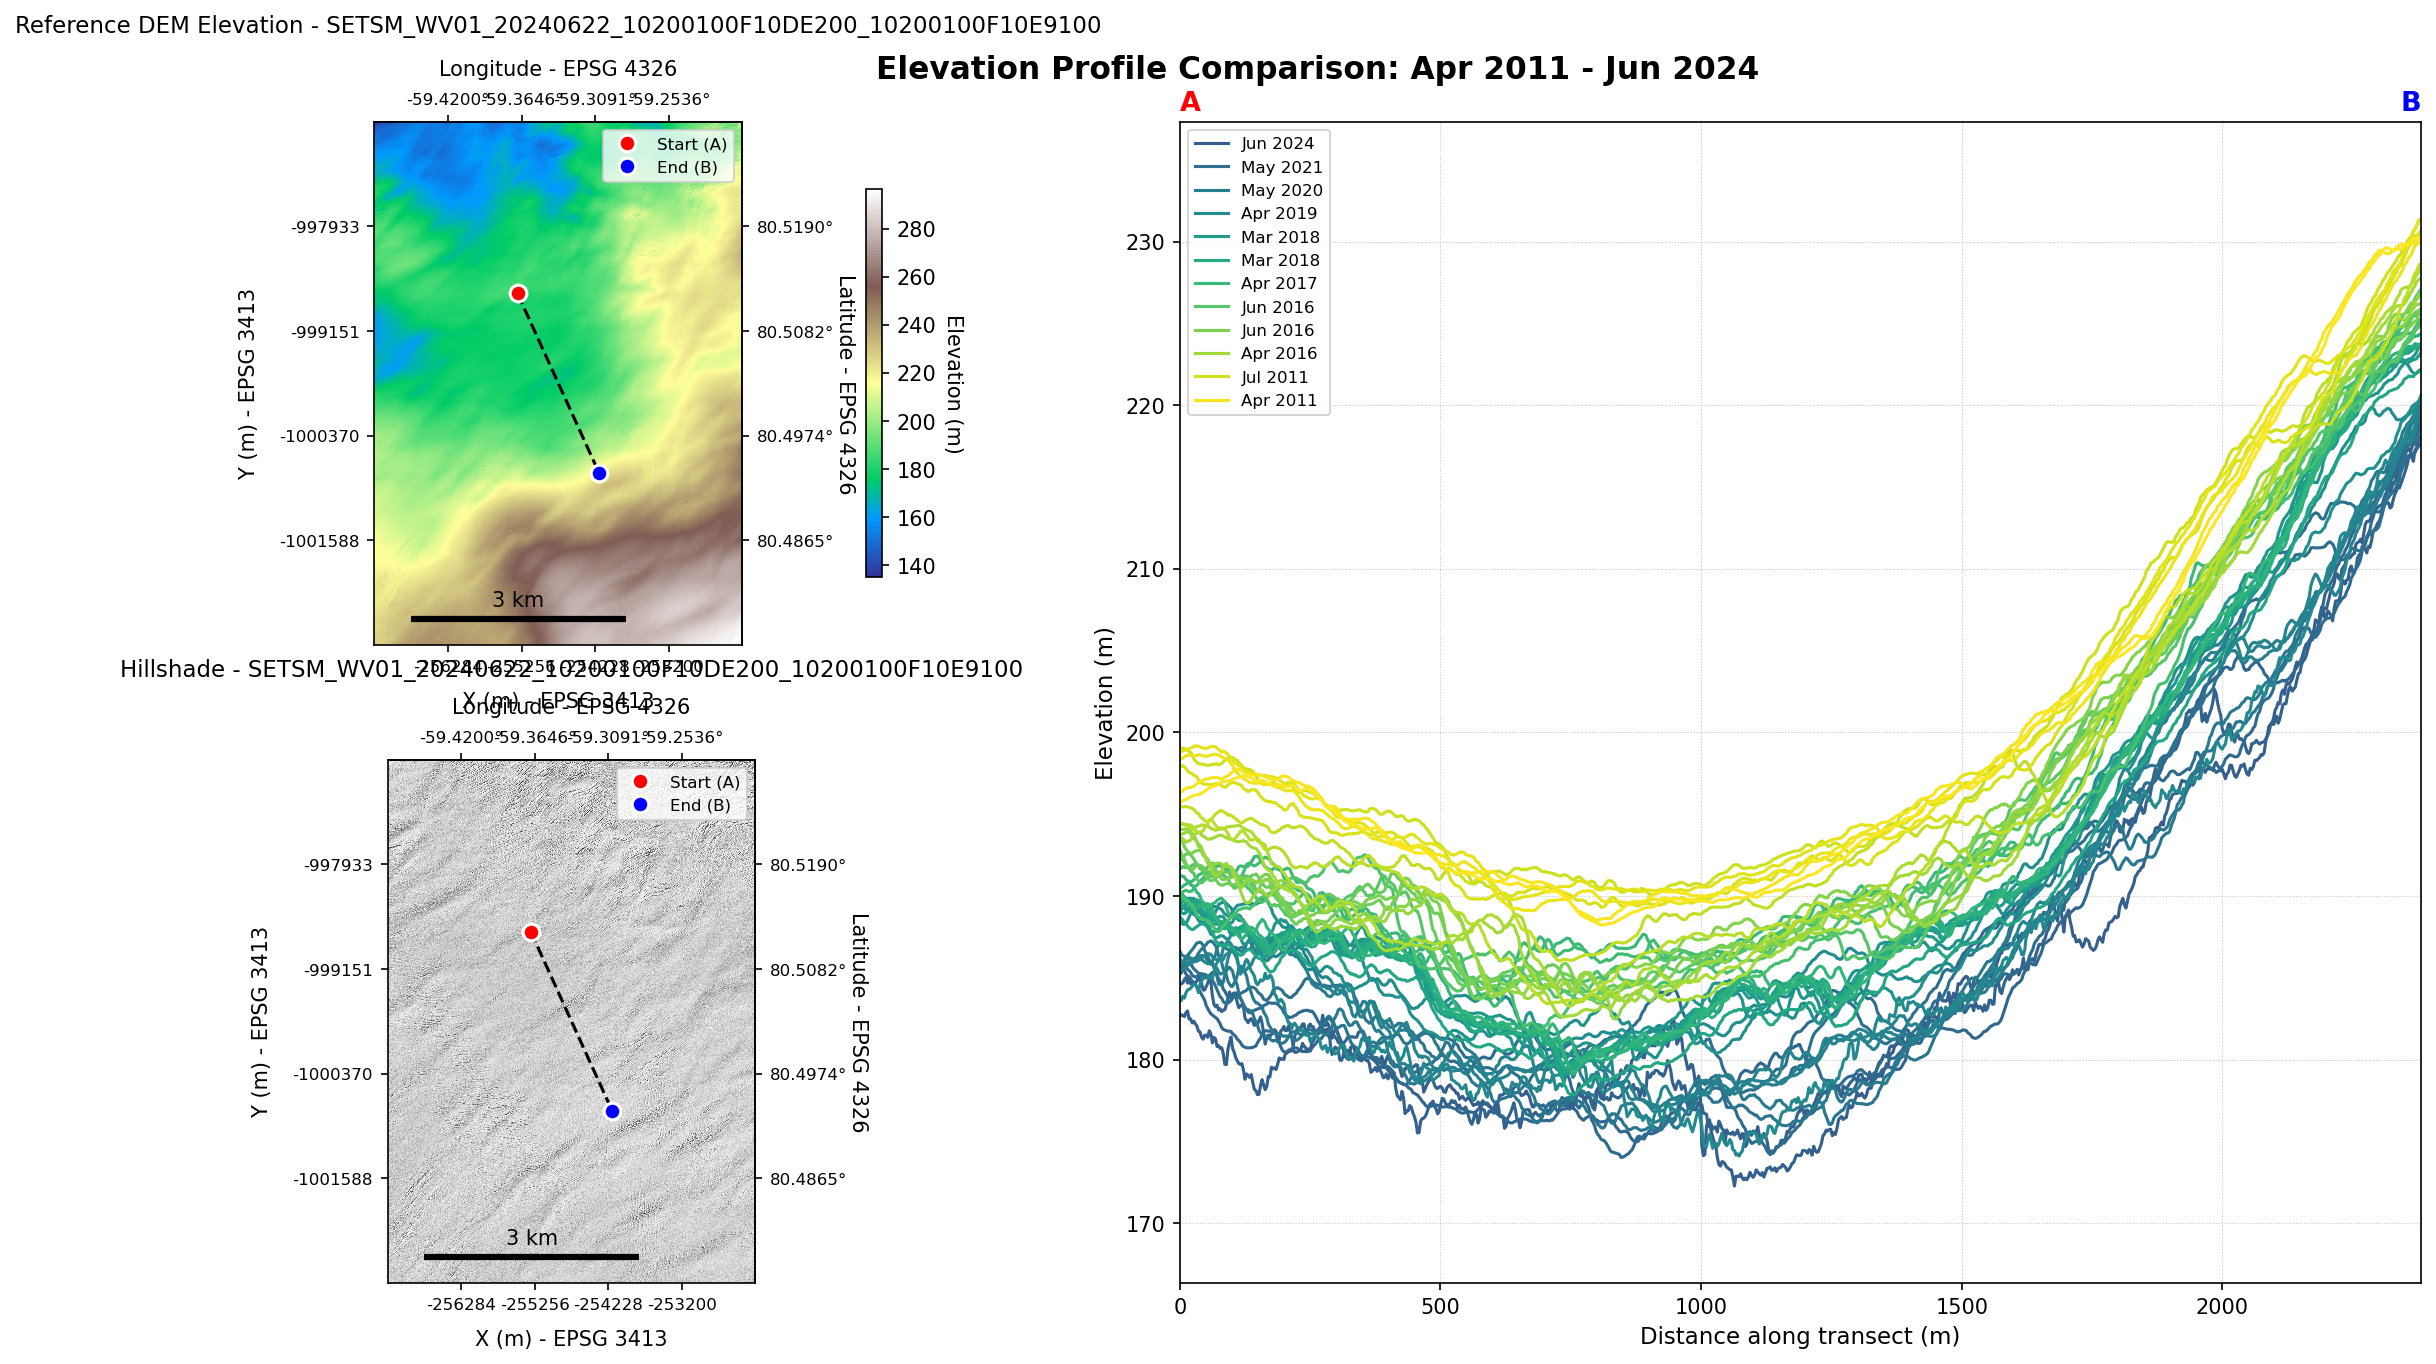


=== Generating elevation change heatmap and relative difference plots ===
dem_name: SETSM_WV02_20110407_103001000AD56900_103001000A1B0E00
Plot saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/transects_combined/profile_diff_-59.340_80.505_-59.250_80.489-2011-2024_mosaic.png


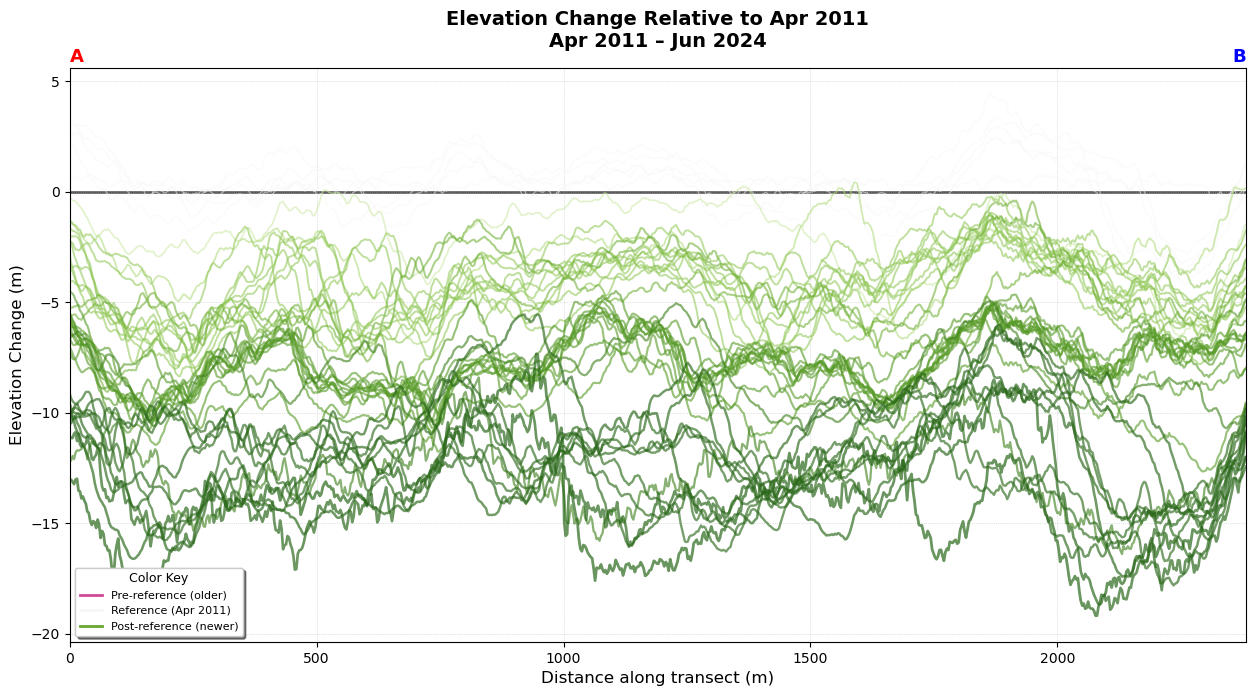


Plot bounds (EPSG:3413):
  left=-257312.1, right=-252172.4
  bottom=-1002806.4, top=-996715.6
  width=5140m, height=6091m
WGS84 extent:
  lon: [-59.475422, -59.115310]
  lat: [80.464108, 80.529872]

Meridians: [-59.47542232 -59.40339989 -59.33137746 -59.25935504 -59.18733261
 -59.11531018]
Parallels: [80.46410808 80.47726093 80.49041377 80.50356662 80.51671947 80.52987231]


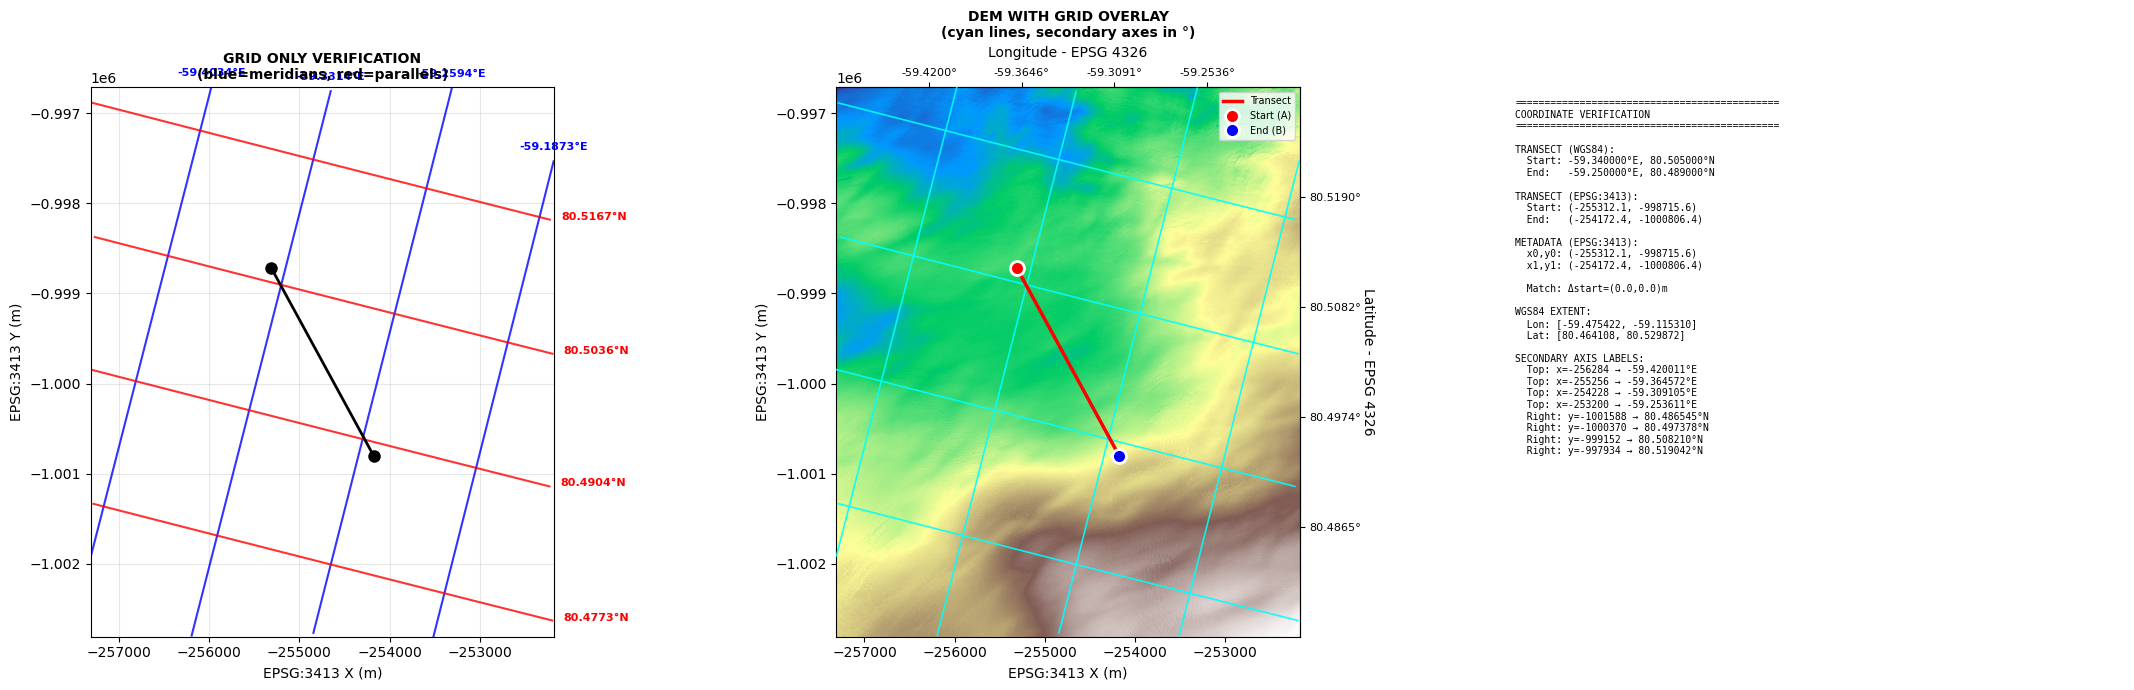


VISUAL CHECK:
Panel 1 (left):  Grid lines on white background
  - Blue vertical-ish lines = meridians (constant longitude)
  - Red horizontal-ish lines = parallels (constant latitude)
  - If you CANNOT see these, the coordinate transform is wrong!

Panel 2 (center): Grid overlaid on DEM
  - Cyan lines should be visible on top of the terrain
  - Secondary axis labels (top/right) should match cyan labels
  - If cyan lines are invisible, check zorder and alpha


In [57]:
# Cell 6: Plots (Elevation Profile Comparison + Heatmap and Relative Change)
"""
## Elevation profiles plot
Original elevation profile comparison plot
## Additional Plots
Heatmap and relative change plots for the profiles.
"""
# Generate plots
plot_path = plot_combined_profiles(
    filtered_profiles, coreg_mode=COREG_MODE, lake_name=LAKE_NAME
)
filtered_profiles['plot_path'] = plot_path

from IPython.display import Image, display

if filtered_profiles.get('plot_path'):
    print(f"Plot saved to: {filtered_profiles['plot_path']}")
    display(Image(filename=filtered_profiles['plot_path']))

additional_plots(filtered_profiles, reference_year=None, coreg_mode=COREG_MODE, lake_name=LAKE_NAME)

from analysis import verify_coordinate_transforms

# Run verification on the processed profiles
if 'all_profiles' in locals():
    verify_coordinate_transforms(all_profiles, margin_km=2)
# elif 'all_transect_results' in locals():
#     # Use the first transect result
#     verify_coordinate_transforms(all_transect_results[0]['profiles'], margin_km=2)
else:
    print("No profile data found. Run the profile extraction first.")

TEMPORAL EVOLUTION ANALYSIS

────────────────────────────────────────────────────────────────────────────────
1. OVERALL ELEVATION TREND
────────────────────────────────────────────────────────────────────────────────
Mean elevation trend: -3.05 m/year
Total change over period: -40.34 m
R² = 0.007, p = 0.5396
Assessment: ⚠️  SIGNIFICANT THINNING DETECTED

────────────────────────────────────────────────────────────────────────────────
2. SPATIAL CHANGE RATE ALONG TRANSECT
────────────────────────────────────────────────────────────────────────────────
Total points along transect: 800
Points with significant change (p<0.05): 0 (0.0%)
Significant thinning (<-0.1 m/yr): 0 points
Significant thickening (>+0.1 m/yr): 0 points

────────────────────────────────────────────────────────────────────────────────
3. LOCALIZED CHANGE DETECTION
────────────────────────────────────────────────────────────────────────────────

───────────────────────────────────────────────────────────────────────────

/tmp/ipykernel_1289890/346443230.py:56: RuntimeWarning: Mean of empty slice
  mean_elevations = np.nanmean(elevation_matrix, axis=1)


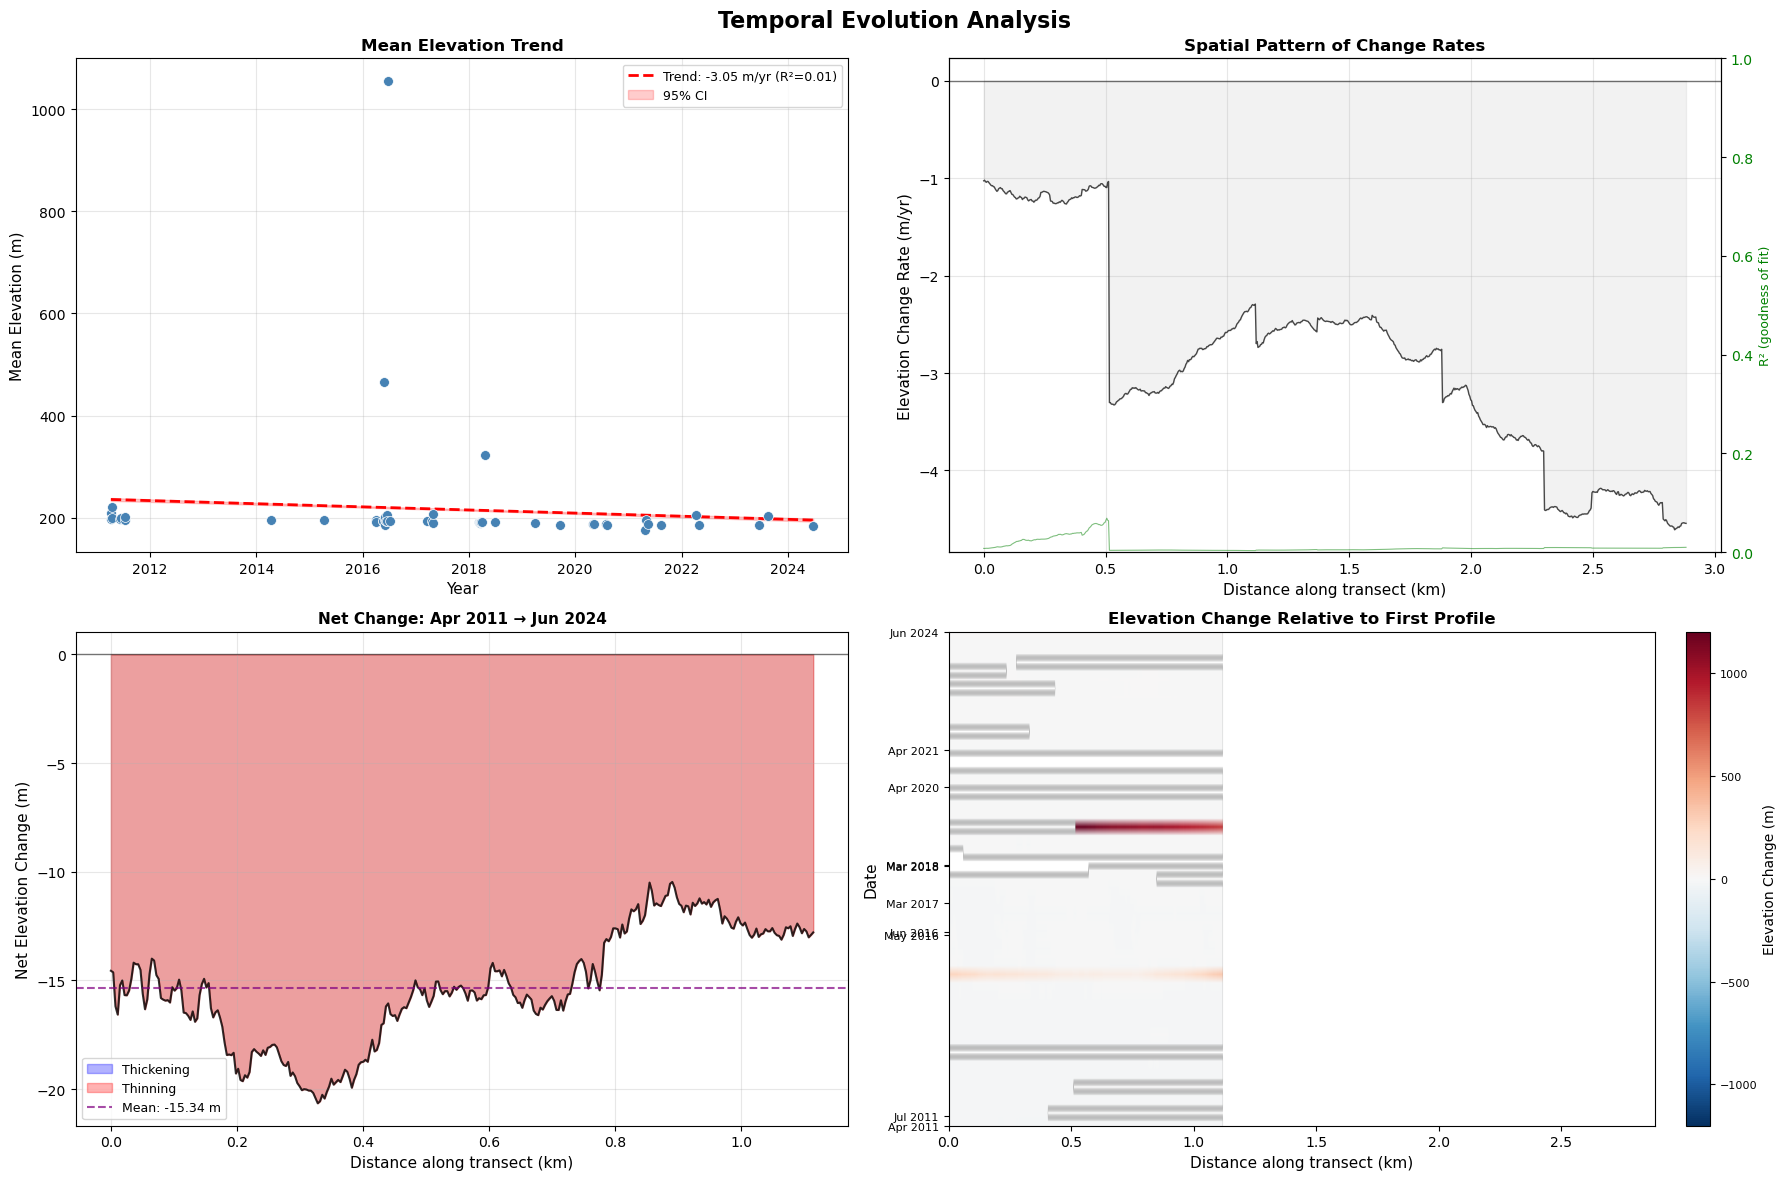


SUMMARY

Metric                                                  Value
--------------------------------------------------------------
Overall trend                                           -3.05 m/yr
Total change                                           -40.34 m
Statistical significance (p)                           0.5396
Mean net change (first–last)                           -15.34 m
Max thinning (single point)                            -20.65 m
Max thickening (single point)                          -10.47 m
Points with significant change                              0 / 800
Potential thinning hotspots                                 0
Potential thickening hotspots                               0

Analysis complete! Interpret with caution — check data quality first.


In [28]:
# Cell 6: Temporal evolution analysis
"""
Temporal Evolution & Change Detection
Analyze how elevation profiles change over time to detect:
- Overall thinning/thickening trends
- Localized changes (potential subglacial lake activity)
- Spatial patterns in elevation change rates
"""
from analysis import extract_date_obj, extract_date_label
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np

print("=" * 80)
print("TEMPORAL EVOLUTION ANALYSIS")
print("=" * 80)

# Sort profiles by date
profiles_sorted = sorted(
    profiles['profiles'],
    key=lambda x: extract_date_obj(x['metadata']['dem_name'])
)

# Extract dates and create common distance grid
dates_list = [extract_date_obj(p['metadata']['dem_name']) for p in profiles_sorted]
distances = profiles_sorted[0]['transect']  # Use first profile as reference distance

# Interpolate all profiles to common distance grid for comparison
n_profiles = len(profiles_sorted)
n_points = len(distances)
elevation_matrix = np.full((n_profiles, n_points), np.nan)

for i, profile in enumerate(profiles_sorted):
    elevations = np.array(profile['profile_values'])
    valid = ~np.isnan(elevations)
    
    if np.sum(valid) > 2:
        # Interpolate to common grid (handle missing values)
        elevation_matrix[i, :] = np.interp(
            distances, 
            profile['transect'][valid], 
            elevations[valid],
            left=np.nan, right=np.nan
        )

# ──────────────────────────────────────────────────────────────────────────
# 1. OVERALL TREND: Mean elevation change over time
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 80)
print("1. OVERALL ELEVATION TREND")
print("─" * 80)

# Calculate mean elevation for each profile (using valid points only)
mean_elevations = np.nanmean(elevation_matrix, axis=1)
valid_means = ~np.isnan(mean_elevations)

if np.sum(valid_means) >= 3:
    # Convert dates to decimal years for regression
    years = np.array([d.year + d.timetuple().tm_yday / 365.25 
                      for d in dates_list])
    
    # Linear regression: elevation vs time
    valid_idx = np.where(valid_means)[0]
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        years[valid_idx], mean_elevations[valid_idx]
    )
    
    total_change = slope * (years[-1] - years[0])
    
    print(f"Mean elevation trend: {slope:+.2f} m/year")
    print(f"Total change over period: {total_change:+.2f} m")
    print(f"R² = {r_value**2:.3f}, p = {p_value:.4f}")
    
    if slope < -0.1:
        trend_text = "⚠️  SIGNIFICANT THINNING DETECTED"
    elif slope < -0.02:
        trend_text = "📉 Moderate thinning trend"
    elif slope > 0.02:
        trend_text = "📈 Thickening trend"
    else:
        trend_text = "➡️  Relatively stable"
    
    print(f"Assessment: {trend_text}")
else:
    print("Insufficient valid data for trend analysis")

# ──────────────────────────────────────────────────────────────────────────
# 2. SPATIAL CHANGE RATE: Elevation change rate along transect
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 80)
print("2. SPATIAL CHANGE RATE ALONG TRANSECT")
print("─" * 80)

# Calculate change rate at each point along transect
change_rates = np.full(n_points, np.nan)
change_pvalues = np.full(n_points, np.nan)
point_r_squared = np.full(n_points, np.nan)

for i in range(n_points):
    point_elevations = elevation_matrix[:, i]
    valid = ~np.isnan(point_elevations)
    
    if np.sum(valid) >= 5:  # Need at least 5 points for regression
        slope_i, _, r_i, p_i, _ = stats.linregress(
            years[valid], point_elevations[valid]
        )
        change_rates[i] = slope_i
        change_pvalues[i] = p_i
        point_r_squared[i] = r_i**2

# Identify significant changes
significant = change_pvalues < 0.05
thinning_points = significant & (change_rates < -0.1)
thickening_points = significant & (change_rates > 0.1)

print(f"Total points along transect: {n_points}")
print(f"Points with significant change (p<0.05): {np.sum(significant)} ({100*np.sum(significant)/n_points:.1f}%)")
print(f"Significant thinning (<-0.1 m/yr): {np.sum(thinning_points)} points")
print(f"Significant thickening (>+0.1 m/yr): {np.sum(thickening_points)} points")

# ──────────────────────────────────────────────────────────────────────────
# 3. LOCALIZED CHANGE DETECTION (potential subglacial lake activity)
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 80)
print("3. LOCALIZED CHANGE DETECTION")
print("─" * 80)

# Look for clusters of rapid change (potential lake activity)
from scipy.ndimage import label

# Find contiguous regions of significant thinning
if np.sum(thinning_points) > 0:
    thinning_regions, n_thinning = label(thinning_points)
    
    print(f"Potential thinning hotspots: {n_thinning}")
    
    for region_id in range(1, n_thinning + 1):
        region_mask = thinning_regions == region_id
        region_size = np.sum(region_mask)
        
        if region_size >= 3:  # At least 3 contiguous points
            region_start = distances[np.where(region_mask)[0][0]]
            region_end = distances[np.where(region_mask)[0][-1]]
            region_mean_rate = np.nanmean(change_rates[region_mask])
            region_max_rate = np.nanmin(change_rates[region_mask])
            
            print(f"\n  Region {region_id}:")
            print(f"    Distance: {region_start:.0f} – {region_end:.0f} m ({region_size} points)")
            print(f"    Mean rate: {region_mean_rate:+.2f} m/yr")
            print(f"    Max thinning: {region_max_rate:+.2f} m/yr")
            
            # Check if rate exceeds typical thinning (potential lake drainage)
            if region_max_rate < -0.5:
                print(f"    ⚠️  RAPID THINNING — possible subglacial lake drainage!")
            elif region_max_rate < -0.2:
                print(f"    🔍 Notable thinning — worth investigating")

# Find contiguous regions of significant thickening
if np.sum(thickening_points) > 0:
    thickening_regions, n_thickening = label(thickening_points)
    
    print(f"\nPotential thickening hotspots: {n_thickening}")
    
    for region_id in range(1, n_thickening + 1):
        region_mask = thickening_regions == region_id
        region_size = np.sum(region_mask)
        
        if region_size >= 3:
            region_start = distances[np.where(region_mask)[0][0]]
            region_end = distances[np.where(region_mask)[0][-1]]
            region_mean_rate = np.nanmean(change_rates[region_mask])
            
            print(f"\n  Region {region_id}:")
            print(f"    Distance: {region_start:.0f} – {region_end:.0f} m ({region_size} points)")
            print(f"    Mean rate: {region_mean_rate:+.2f} m/yr")
            
            if region_mean_rate > 0.5:
                print(f"    💧 Possible subglacial lake filling!")

# ──────────────────────────────────────────────────────────────────────────
# 4. ELEVATION CHANGE BETWEEN FIRST AND LAST PROFILE
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 80)
print("4. NET CHANGE: First vs Last Profile")
print("─" * 80)

# Compare first and last valid profiles
first_valid_idx = np.where(valid_means)[0][0]
last_valid_idx = np.where(valid_means)[0][-1]

first_profile = elevation_matrix[first_valid_idx, :]
last_profile = elevation_matrix[last_valid_idx, :]

# Calculate point-by-point difference
net_change = last_profile - first_profile
valid_change = ~np.isnan(net_change)

if np.sum(valid_change) > 0:
    print(f"First profile: {extract_date_label(profiles_sorted[first_valid_idx]['metadata']['dem_name'])}")
    print(f"Last profile:  {extract_date_label(profiles_sorted[last_valid_idx]['metadata']['dem_name'])}")
    print(f"Time span: {(years[last_valid_idx] - years[first_valid_idx]):.1f} years")
    print(f"Net change statistics along transect:")
    print(f"  Mean: {np.nanmean(net_change):+.2f} m")
    print(f"  Median: {np.nanmedian(net_change):+.2f} m")
    print(f"  Min: {np.nanmin(net_change):+.2f} m (max thinning)")
    print(f"  Max: {np.nanmax(net_change):+.2f} m (max thickening)")
    print(f"  Std: {np.nanstd(net_change):.2f} m")
    
    # Percentage of transect showing thinning vs thickening
    pct_thinning = 100 * np.sum(net_change[valid_change] < 0) / np.sum(valid_change)
    pct_thickening = 100 * np.sum(net_change[valid_change] > 0) / np.sum(valid_change)
    
    print(f"\n  Thinning: {pct_thinning:.1f}% of transect")
    print(f"  Thickening: {pct_thickening:.1f}% of transect")

# ──────────────────────────────────────────────────────────────────────────
# 5. VISUALIZATION: Multi-panel temporal analysis plot
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 80)
print("5. Generating temporal analysis visualization...")
print("─" * 80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Temporal Evolution Analysis', fontsize=16, fontweight='bold', y=0.98)

# Panel 1: Mean elevation over time
ax1 = axes[0, 0]
if np.sum(valid_means) >= 3:
    ax1.scatter(years[valid_means], mean_elevations[valid_means], 
               c='steelblue', s=50, zorder=5, edgecolors='white', linewidth=0.5)
    
    # Trend line
    trend_y = slope * years[valid_idx] + intercept
    ax1.plot(years[valid_idx], trend_y, 'r--', linewidth=2, 
            label=f'Trend: {slope:+.2f} m/yr (R²={r_value**2:.2f})')
    
    # Confidence band
    n = len(valid_idx)
    conf_interval = std_err * 1.96 * np.sqrt(1/n + (years[valid_idx] - np.mean(years[valid_idx]))**2 / 
                                             np.sum((years[valid_idx] - np.mean(years[valid_idx]))**2))
    ax1.fill_between(years[valid_idx], trend_y - conf_interval, trend_y + conf_interval,
                    alpha=0.2, color='red', label='95% CI')
    
    ax1.legend(fontsize=9)
    
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Mean Elevation (m)', fontsize=11)
ax1.set_title('Mean Elevation Trend', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Panel 2: Change rate along transect
ax2 = axes[0, 1]
dist_km = distances / 1000  # Convert to km

# Plot change rate
ax2.fill_between(dist_km, 0, change_rates, alpha=0.1, color='gray')
ax2.plot(dist_km, change_rates, 'k-', linewidth=1, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Highlight significant changes
if np.sum(significant) > 0:
    ax2.scatter(dist_km[thinning_points], change_rates[thinning_points], 
               c='red', s=20, alpha=0.6, label=f'Thinning (n={np.sum(thinning_points)})', zorder=5)
    ax2.scatter(dist_km[thickening_points], change_rates[thickening_points], 
               c='blue', s=20, alpha=0.6, label=f'Thickening (n={np.sum(thickening_points)})', zorder=5)
    ax2.legend(fontsize=8, loc='lower left')

# Add R² information
ax2_twin = ax2.twinx()
ax2_twin.plot(dist_km, point_r_squared, 'g-', linewidth=0.8, alpha=0.5, label='R²')
ax2_twin.set_ylabel('R² (goodness of fit)', fontsize=9, color='green')
ax2_twin.tick_params(axis='y', labelcolor='green')
ax2_twin.set_ylim(0, 1)

ax2.set_xlabel('Distance along transect (km)', fontsize=11)
ax2.set_ylabel('Elevation Change Rate (m/yr)', fontsize=11)
ax2.set_title('Spatial Pattern of Change Rates', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Panel 3: Net change (first vs last)
ax3 = axes[1, 0]
if np.sum(valid_change) > 0:
    ax3.fill_between(dist_km, 0, net_change, alpha=0.2, color='gray')
    ax3.plot(dist_km, net_change, 'k-', linewidth=1.5, alpha=0.8)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # Color regions by sign of change
    positive = net_change > 0
    negative = net_change < 0
    ax3.fill_between(dist_km, 0, net_change, 
                    where=positive, alpha=0.3, color='blue', label='Thickening')
    ax3.fill_between(dist_km, 0, net_change, 
                    where=negative, alpha=0.3, color='red', label='Thinning')
    
    # Add mean net change line
    mean_net = np.nanmean(net_change)
    ax3.axhline(y=mean_net, color='purple', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Mean: {mean_net:+.2f} m')
    
    ax3.legend(fontsize=9)

ax3.set_xlabel('Distance along transect (km)', fontsize=11)
ax3.set_ylabel('Net Elevation Change (m)', fontsize=11)
ax3.set_title(f'Net Change: {extract_date_label(profiles_sorted[first_valid_idx]["metadata"]["dem_name"])} → '
             f'{extract_date_label(profiles_sorted[last_valid_idx]["metadata"]["dem_name"])}', 
             fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Panel 4: Elevation change heatmap (time vs distance)
ax4 = axes[1, 1]

# Create heatmap of elevation changes relative to first profile
change_matrix = elevation_matrix - elevation_matrix[first_valid_idx, :]
change_matrix = np.ma.masked_invalid(change_matrix)

max_abs = np.nanmax(np.abs(change_matrix))
vlim = max(5, max_abs)

im = ax4.imshow(change_matrix, aspect='auto', cmap='RdBu_r',
               extent=[dist_km[0], dist_km[-1], years[0], years[-1]],
               vmin=-vlim, vmax=vlim, interpolation='bilinear')

# Format
date_labels = [extract_date_label(p['metadata']['dem_name']) for p in profiles_sorted]
n_labels = min(len(date_labels), 10)
tick_indices = np.linspace(0, len(date_labels)-1, n_labels, dtype=int)
tick_years = [years[i] for i in tick_indices]
tick_labels = [date_labels[i] for i in tick_indices]

ax4.set_yticks(tick_years)
ax4.set_yticklabels(tick_labels, fontsize=8)
ax4.set_xlabel('Distance along transect (km)', fontsize=11)
ax4.set_ylabel('Date', fontsize=11)
ax4.set_title('Elevation Change Relative to First Profile', fontsize=12, fontweight='bold')

cbar = plt.colorbar(im, ax=ax4, label='Elevation Change (m)', fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────
# 6. SUMMARY TABLE
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

print(f"\n{'Metric':<40} {'Value':>20}")
print("-" * 62)

if np.sum(valid_means) >= 3:
    print(f"{'Overall trend':<40} {slope:>+20.2f} m/yr")
    print(f"{'Total change':<40} {total_change:>+20.2f} m")
    print(f"{'Statistical significance (p)':<40} {p_value:>20.4f}")

if np.sum(valid_change) > 0:
    print(f"{'Mean net change (first–last)':<40} {np.nanmean(net_change):>+20.2f} m")
    print(f"{'Max thinning (single point)':<40} {np.nanmin(net_change):>+20.2f} m")
    print(f"{'Max thickening (single point)':<40} {np.nanmax(net_change):>+20.2f} m")

print(f"{'Points with significant change':<40} {np.sum(significant):>20} / {n_points}")
print(f"{'Potential thinning hotspots':<40} {n_thinning if np.sum(thinning_points) > 0 else 0:>20}")
print(f"{'Potential thickening hotspots':<40} {n_thickening if np.sum(thickening_points) > 0 else 0:>20}")

print("\n" + "=" * 80)
print("Analysis complete! Interpret with caution — check data quality first.")
print("=" * 80)


In [30]:
all_profiles 

{'transect_coords': ((-59.22, 80.495), (-59.38, 80.495)),
 'profiles': [{'transect': array([   0.        ,    3.60660003,    7.21320006,   10.8198001 ,
            14.42640013,   18.03300016,   21.63960019,   25.24620023,
            28.85280026,   32.45940029,   36.06600032,   39.67260036,
            43.27920039,   46.88580042,   50.49240045,   54.09900048,
            57.70560052,   61.31220055,   64.91880058,   68.52540061,
            72.13200065,   75.73860068,   79.34520071,   82.95180074,
            86.55840077,   90.16500081,   93.77160084,   97.37820087,
           100.9848009 ,  104.59140094,  108.19800097,  111.804601  ,
           115.41120103,  119.01780107,  122.6244011 ,  126.23100113,
           129.83760116,  133.44420119,  137.05080123,  140.65740126,
           144.26400129,  147.87060132,  151.47720136,  155.08380139,
           158.69040142,  162.29700145,  165.90360149,  169.51020152,
           173.11680155,  176.72340158,  180.33000161,  183.93660165,
        


Plot bounds (EPSG:3413):
  left=-258280.1, right=-251487.7
  bottom=-1002305.1, top=-997593.4
  width=6792m, height=4712m
WGS84 extent:
  lon: [-59.515335, -59.085267]
  lat: [80.466349, 80.523605]

Meridians: [-59.51533475 -59.42932121 -59.34330768 -59.25729414 -59.1712806
 -59.08526707]
Parallels: [80.46634947 80.47780056 80.48925164 80.50070273 80.51215381 80.5236049 ]


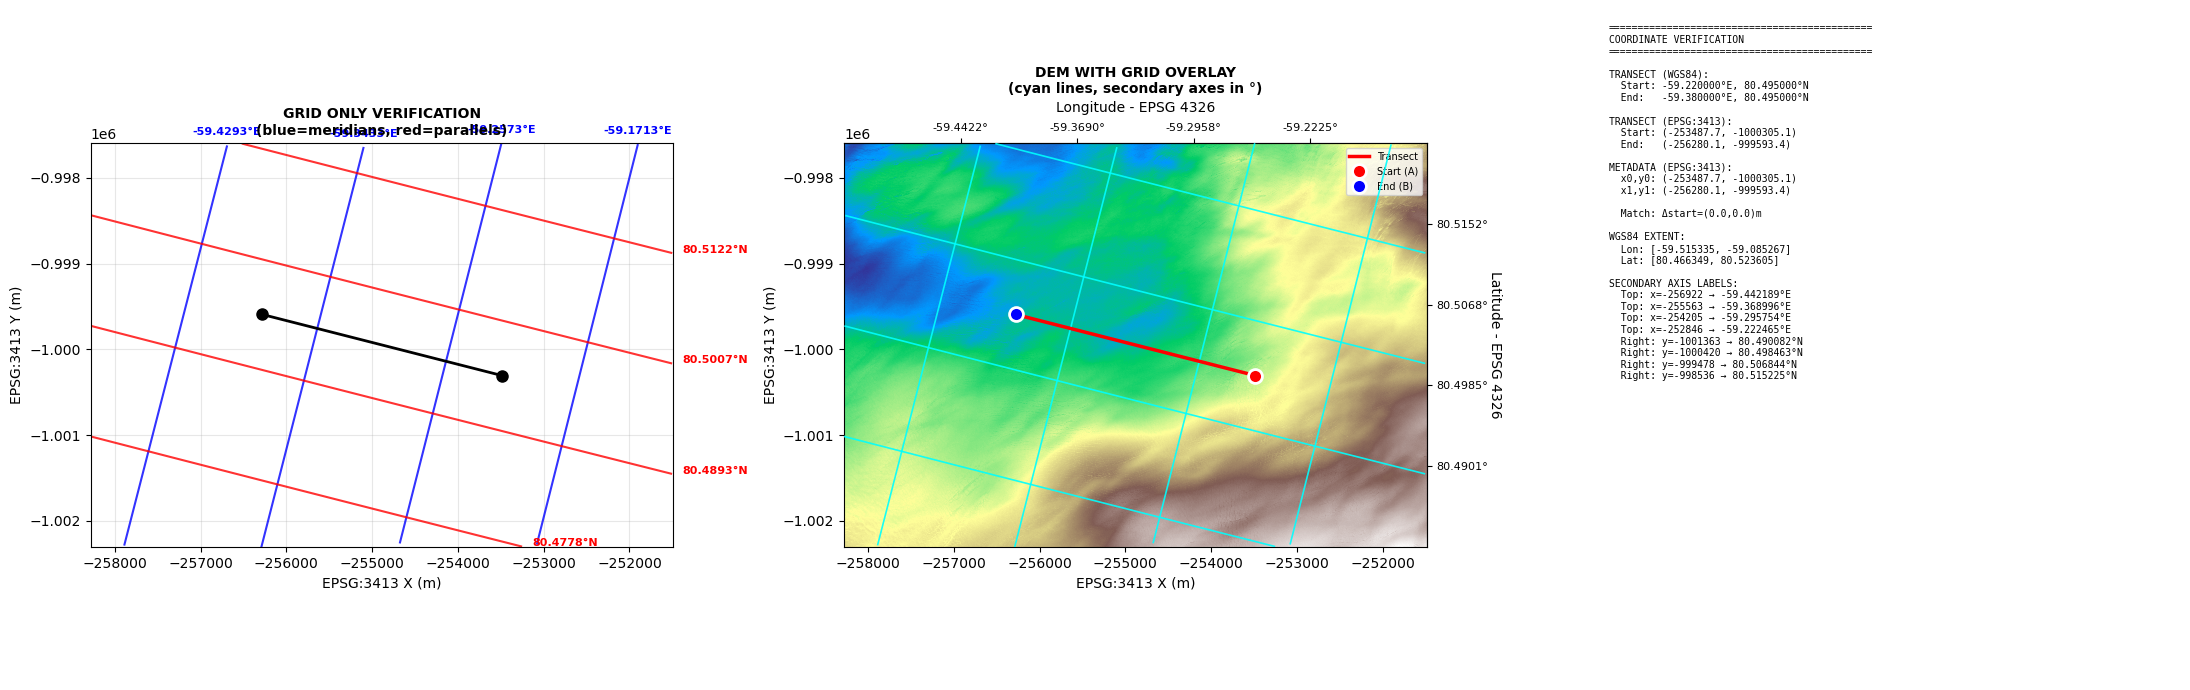


VISUAL CHECK:
Panel 1 (left):  Grid lines on white background
  - Blue vertical-ish lines = meridians (constant longitude)
  - Red horizontal-ish lines = parallels (constant latitude)
  - If you CANNOT see these, the coordinate transform is wrong!

Panel 2 (center): Grid overlaid on DEM
  - Cyan lines should be visible on top of the terrain
  - Secondary axis labels (top/right) should match cyan labels
  - If cyan lines are invisible, check zorder and alpha


In [49]:
# Cell X: Coordinate Verification
"""
## Verify Coordinate Transformations
Check that the transect coordinates, axis labels, and 
georeferencing are all correct.
"""
import importlib
import analysis
importlib.reload(analysis)
from analysis import verify_coordinate_transforms

# Run verification on the processed profiles
if 'all_profiles' in locals():
    verify_coordinate_transforms(all_profiles, margin_km=2)
# elif 'all_transect_results' in locals():
#     # Use the first transect result
#     verify_coordinate_transforms(all_transect_results[0]['profiles'], margin_km=2)
else:
    print("No profile data found. Run the profile extraction first.")

In [ ]:
# Cell 7: Subglacial Lake Detection
"""
## Subglacial Lake Detection
Identify potential subglacial lake boundaries based on localized elevation
changes in the profile data. Lakes appear as regions where the surface 
elevation changes rapidly compared to surrounding areas.
"""
import lake_detection  # Ensure lake_detection module is imported
importlib.reload(lake_detection)  # Reload the analysis module to ensure latest changes are used
# from analysis import detect_lake_boundaries, plot_lake_detection_results
from lake_detection import detect_lake_boundaries, plot_lake_detection_results

print("Running lake detection algorithm...")
print("This looks for localized elevation changes that may indicate")
print("active subglacial lakes beneath the transect.\n")

# Run detection
lake_results = detect_lake_boundaries(
    profiles,  # Use filtered profiles
    min_depth=2.0,                   # Minimum 1.5m elevation change
    min_span_meters=200,             # At least 100m wide
    max_span_meters=5000,            # At most 5km wide
    min_profiles_showing=3,         # At least 1 profile must show anomaly
    smooth_window=3,                 # Smoothing for noise reduction
    prominence_threshold=0.5,      # Fraction of span to search for boundaries (15%)
    verbose=True
)

# Display results
if lake_results['lake_boundaries']:
    print(f"\n{'='*80}")
    print(f"DETECTED LAKE CANDIDATES: {len(lake_results['lake_boundaries'])}")
    print(f"{'='*80}")
    
    for i, lake in enumerate(lake_results['lake_boundaries']):
        print(f"\nLake Candidate {i+1}:")
        print(f"  Distance along transect: {lake['start_distance']:.0f} – {lake['end_distance']:.0f} m")
        print(f"  Span: {lake['span_meters']:.0f} m")
        print(f"  EPSG:3413 start: ({lake['start_coords_3413'][0]:.1f}, {lake['start_coords_3413'][1]:.1f})")
        print(f"  EPSG:3413 end:   ({lake['end_coords_3413'][0]:.1f}, {lake['end_coords_3413'][1]:.1f})")
        print(f"  WGS84 start: ({lake['start_coords_4326'][0]:.6f}°E, {lake['start_coords_4326'][1]:.6f}°N)")
        print(f"  WGS84 end:   ({lake['end_coords_4326'][0]:.6f}°E, {lake['end_coords_4326'][1]:.6f}°N)")
        print(f"  Confidence: {lake['confidence']:.2f}")
        print(f"  Profiles affected: {lake['n_profiles_affected']}")
else:
    print(f"\n{'='*80}")
    print(f"NO LAKE CANDIDATES DETECTED")
    print(f"{'='*80}")
    print("No regions with significant localized elevation changes found.")
    print("This transect may not intersect any active subglacial lakes,")
    print("or the signal may be below the detection threshold.")

# Generate lake detection plot
print("\nGenerating lake detection visualization...")
lake_plot_path = plot_lake_detection_results(
    profiles,
    lake_results,
    coreg_mode=COREG_MODE,
    lake_name=LAKE_NAME
)

print(f"\n✓ Lake detection analysis complete!")

Running lake detection algorithm...
This looks for localized elevation changes that may indicate
active subglacial lakes beneath the transect.


SUBSGLACIAL LAKE DETECTION
Profiles: 59
Transect points: 800
Spatial resolution: 5.9 m
Median elevation range: 162 – 217 m
Median IQR: 5.20 m

Anomaly threshold: 0.1563
Peaks found: 4
  ✓ LAKE CANDIDATE 1:
    Peak at 2672m, bulge
    Boundaries: 1957 – 2790m (span: 832m)
    Confidence: 0.67 | Profiles affected: 30.0
  Peak at 3710m: span 182m - rejected (size)
  ✓ LAKE CANDIDATE 2:
    Peak at 4003m, bulge
    Boundaries: 3774 – 4097m (span: 322m)
    Confidence: 0.65 | Profiles affected: 29.0
  ✓ LAKE CANDIDATE 3:
    Peak at 4261m, bulge
    Boundaries: 4097 – 4466m (span: 369m)
    Confidence: 0.68 | Profiles affected: 31.0

  Final: 3 non-overlapping lake candidate(s).

DETECTED LAKE CANDIDATES: 3

Lake Candidate 1:
  Distance along transect: 1957 – 2790 m
  Span: 832 m
  EPSG:3413 start: (-255384.1, -999820.0)
  EPSG:3413 end:   (-25619